In [1]:
import numpy as np
import pandas as pd
import time
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, 
    roc_auc_score, confusion_matrix
)
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SVMSMOTE, SMOTE, SMOTENC,ADASYN
import numpy as np
import pandas as pd
import time
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, 
    roc_auc_score, confusion_matrix
)
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SVMSMOTE

In [2]:
df_train = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\05092025_raw_data_v2\process_train.csv")
df_test = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\05092025_raw_data_v2\processed_test.csv")

In [3]:
columns_remove_train = [
    'VitaminD',
    'YearStart',
     'YearID'
]

In [4]:
columns_remove_test = [
    'VitaminD',
    'YearStart',
]

In [5]:
df_train.drop(columns=columns_remove_train, inplace=True)

In [6]:
df_test.drop(columns=columns_remove_test, inplace=True)

In [7]:
print(df_train['label'].value_counts())
print(df_test['label'].value_counts())

label
0.0    16303
1.0     5575
Name: count, dtype: int64
label
0.0    2098
1.0     951
Name: count, dtype: int64


In [8]:
# df_train = df_train[df_train['milk_consumption']<=3]
df_test = df_test[df_test['milk_consumption']<=3]

In [9]:
print(df_train['label'].value_counts())
print(df_test['label'].value_counts())

label
0.0    16303
1.0     5575
Name: count, dtype: int64
label
0.0    2090
1.0     948
Name: count, dtype: int64


## Feature importances before SMOTE

c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:55:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


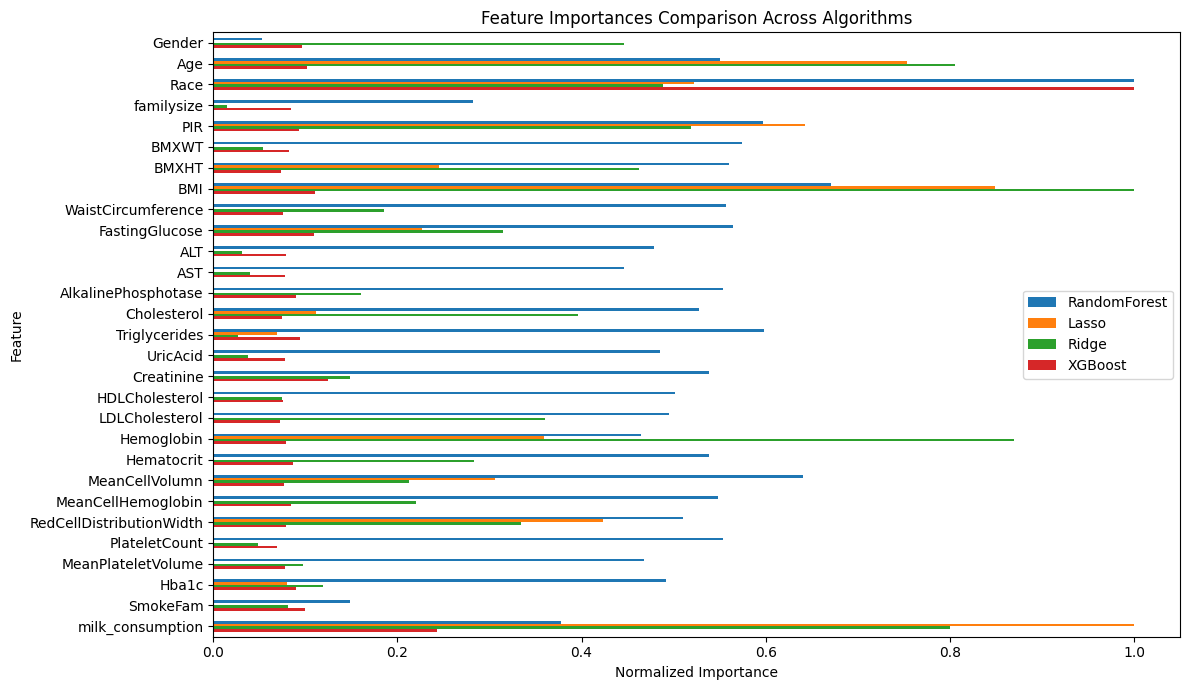

                     Feature  RandomForest     Lasso     Ridge   XGBoost
2                       Race      1.000000  0.522370  0.488882  1.000000
7                        BMI      0.671449  0.848722  1.000000  0.110270
21            MeanCellVolumn      0.640959  0.305952  0.212872  0.076431
14             Triglycerides      0.597816  0.069381  0.027172  0.093961
4                        PIR      0.597551  0.643011  0.518749  0.093393
5                      BMXWT      0.573764  0.000000  0.054036  0.082164
9             FastingGlucose      0.563973  0.226643  0.314245  0.109538
6                      BMXHT      0.560273  0.245206  0.462650  0.073593
8         WaistCircumference      0.556899  0.000000  0.185684  0.075845
24             PlateletCount      0.554134  0.000000  0.048063  0.069635
12       AlkalinePhosphotase      0.554117  0.000000  0.160068  0.089729
1                        Age      0.549964  0.753238  0.805392  0.101334
22        MeanCellHemoglobin      0.548061  0.00000

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
import xgboost as xgb
import matplotlib.pyplot as plt

# Load dataset

X = df_train.drop(columns=['label'])  # Drop non-features
y = df_train['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Standardize for linear models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_importance = rf.feature_importances_

# 2. Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y_train)
lasso_importance = np.abs(lasso.coef_)

# 3. Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y_train)
ridge_importance = np.abs(ridge.coef_)

# 4. XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_importance = xgb_model.feature_importances_

# Aggregate results into a DataFrame
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RandomForest': rf_importance,
    'Lasso': lasso_importance,
    'Ridge': ridge_importance,
    'XGBoost': xgb_importance
})

# Normalize for visualization
for col in ['RandomForest', 'Lasso', 'Ridge', 'XGBoost']:
    importance_df[col] = importance_df[col] / importance_df[col].max()

# Plot top 10 features by Random Forest
top_features = importance_df.sort_values(by='RandomForest', ascending=False).head(30)['Feature']

importance_df_top = importance_df[importance_df['Feature'].isin(top_features)]

importance_df_top.set_index('Feature').plot(kind='barh', figsize=(12, 7))
plt.title("Feature Importances Comparison Across Algorithms")
plt.xlabel("Normalized Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print all results
print(importance_df.sort_values(by='RandomForest', ascending=False).head(30))


## Feature importances after SMOTE

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_23912\3106090006.py:30: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("✅ Before SMOTE:", np.bincount(y_train))
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_23912\3106090006.py:31: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("✅ After  SMOTE:", np.bincount(y_train_res))


✅ Before SMOTE: [12227  4181]
✅ After  SMOTE: [12227 12227]


c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:56:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


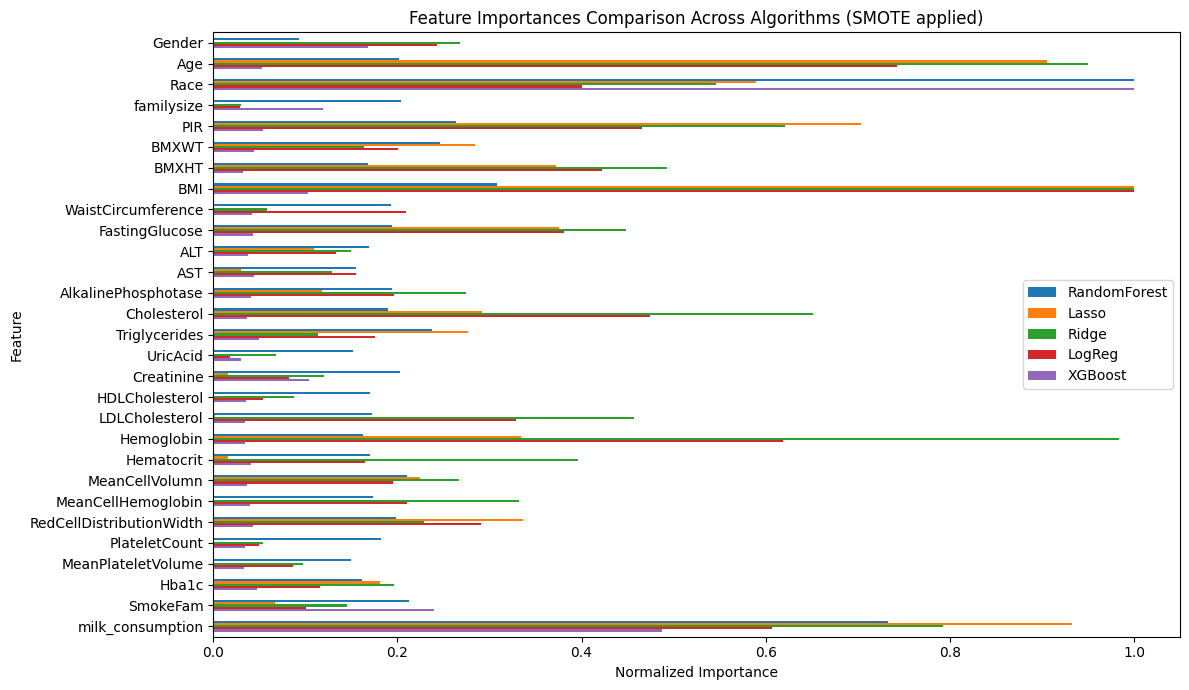

                     Feature  RandomForest     Lasso     Ridge    LogReg  \
2                       Race      1.000000  0.589165  0.545772  0.400704   
28          milk_consumption      0.733038  0.932749  0.792749  0.606511   
7                        BMI      0.308141  1.000000  1.000000  1.000000   
4                        PIR      0.263208  0.703539  0.621099  0.465973   
5                      BMXWT      0.246561  0.284547  0.163824  0.200132   
14             Triglycerides      0.237402  0.276182  0.114263  0.175178   
27                  SmokeFam      0.212934  0.066689  0.145056  0.100269   
21            MeanCellVolumn      0.210592  0.224154  0.266918  0.195393   
3                 familysize      0.204264  0.000000  0.030530  0.028950   
16                Creatinine      0.202430  0.015984  0.120300  0.082019   
1                        Age      0.201854  0.905695  0.949612  0.742345   
23  RedCellDistributionWidth      0.198819  0.335867  0.229246  0.291260   
12       Alk

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
import xgboost as xgb
import matplotlib.pyplot as plt
from imblearn.over_sampling import SVMSMOTE

# ================================
# 1. Load dataset
# ================================
X = df_train.drop(columns=['label'])  # Drop non-features
y = df_train['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

# ================================
# 2. Apply SVM-SMOTE on training set
# ================================
svmsmote = SVMSMOTE(
    random_state=42,
    sampling_strategy="auto",
    k_neighbors=5,
    m_neighbors=10
)
X_train_res, y_train_res = svmsmote.fit_resample(X_train, y_train)
print("✅ Before SMOTE:", np.bincount(y_train))
print("✅ After  SMOTE:", np.bincount(y_train_res))

# ================================
# 3. Standardize for linear models (after SMOTE)
# ================================
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ================================
# 4. Train models
# ================================
# 4.1 Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
rf_importance = rf.feature_importances_

# 4.2 Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_res_scaled, y_train_res)
lasso_importance = np.abs(lasso.coef_)

# 4.3 Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_res_scaled, y_train_res)
ridge_importance = np.abs(ridge.coef_)

# 4.4 Logistic Regression (optional, good for feature selection)
logreg = LogisticRegression(max_iter=500, random_state=42)
logreg.fit(X_train_res_scaled, y_train_res)
logreg_importance = np.abs(logreg.coef_[0])

# 4.5 XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_res, y_train_res)
xgb_importance = xgb_model.feature_importances_

# ================================
# 5. Aggregate results
# ================================
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RandomForest': rf_importance,
    'Lasso': lasso_importance,
    'Ridge': ridge_importance,
    'LogReg': logreg_importance,
    'XGBoost': xgb_importance
})

# Normalize importances for comparison
for col in ['RandomForest', 'Lasso', 'Ridge', 'LogReg', 'XGBoost']:
    importance_df[col] = importance_df[col] / importance_df[col].max()

# ================================
# 6. Visualization
# ================================
top_features = importance_df.sort_values(by='RandomForest', ascending=False).head(30)['Feature']
importance_df_top = importance_df[importance_df['Feature'].isin(top_features)]

importance_df_top.set_index('Feature').plot(kind='barh', figsize=(12, 7))
plt.title("Feature Importances Comparison Across Algorithms (SMOTE applied)")
plt.xlabel("Normalized Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ================================
# 7. Print results
# ================================
print(importance_df.sort_values(by='RandomForest', ascending=False).head(30))


In [10]:
category_columns = [
    'Gender','Race' ,'label'
]

In [11]:
unuseful_features = ['BMXWT', 'BMXHT','Cholesterol','SmokeFam','WaistCircumference','familysize','UricAcid','LDLCholesterol','Hematocrit','PlateletCount', 'MeanPlateletVolume']

In [12]:
df_train.drop(columns=unuseful_features,inplace=True)
df_test = df_test[df_train.columns]

In [14]:
print(len(df_train.columns))

19


In [13]:
#model definition
from sklearn.ensemble import AdaBoostClassifier


dt_setups = {
    "Shallow": DecisionTreeClassifier(criterion="gini", max_depth=5, min_samples_split=10, min_samples_leaf=4, random_state=42),
    "Balanced": DecisionTreeClassifier(criterion="entropy", max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42),
    "Deep": DecisionTreeClassifier(criterion="gini", max_depth=20, min_samples_split=2, min_samples_leaf=1, random_state=42),
    "Randomized": DecisionTreeClassifier(criterion="log_loss", splitter="random", max_depth=None, min_samples_split=20, min_samples_leaf=6, random_state=42),
    "WideFeatures": DecisionTreeClassifier(criterion="entropy", splitter="best", max_depth=30, min_samples_split=5, min_samples_leaf=2, max_features="sqrt", random_state=42)
}
gbc_setups = {
    "Balanced": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "ShallowFast": GradientBoostingClassifier(n_estimators=80, learning_rate=0.2, max_depth=2, subsample=0.8, random_state=42),
    "Regularized": GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=4, min_samples_split=20, min_samples_leaf=5, random_state=42),
    "Deep": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.9, random_state=42),
    "RobustSubsample": GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=5, subsample=0.7, max_features="sqrt", random_state=42),
    "Conservative": GradientBoostingClassifier(n_estimators=500, learning_rate=0.01, max_depth=3, subsample=0.8, max_features="log2", random_state=42)
}

rf_setups = {
    "Balanced": RandomForestClassifier(
        n_estimators=100, max_depth=None, random_state=42
    ),
    "ShallowFast": RandomForestClassifier(
        n_estimators=50, max_depth=5, max_features="sqrt", random_state=42
    ),
    "Deep": RandomForestClassifier(
        n_estimators=300, max_depth=20, min_samples_split=5,
        min_samples_leaf=2, random_state=42
    ),
    "Regularized": RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=10,
        min_samples_leaf=4, max_features=0.6, random_state=42
    ),
    "Conservative": RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_split=20,
        min_samples_leaf=10, max_features="log2", random_state=42
    ),
    "RobustSubsample": RandomForestClassifier(#no ok
        n_estimators=150, max_depth=15, min_samples_split=5,
        min_samples_leaf=3, bootstrap=True, max_features="sqrt",
        random_state=42
    ),
    "Lightweight": RandomForestClassifier(
        n_estimators=50, max_depth=8, max_features=0.5, random_state=42
    ),
    "Heavy": RandomForestClassifier(
        n_estimators=1000, max_depth=None, min_samples_split=2,
        min_samples_leaf=1, max_features=None, random_state=42, n_jobs=-1
    ),
}

#Best: GradientBoostingClassifier(n_estimators=80, learning_rate=0.05, random_state=42)
base_learners = [
    ('lightgbm', LGBMClassifier(n_estimators=100, max_depth=6, num_leaves=31, learning_rate=0.05, random_state=42)),
    #('xgboost', XGBClassifier(n_estimators=80, learning_rate=0.066, random_state=42, verbosity=0)),
    # ('gb', GradientBoostingClassifier(n_estimators=80, learning_rate=0.05, random_state=42)),
    ('RandomForest', rf_setups['Regularized']),
    # ('dt', dt_setups['Shallow']),  
    # ('LogisticRegression', LogisticRegression(max_iter=1000, random_state=42)),
    #('SVM', SVC(kernel='rbf', C=10, gamma='auto', class_weight='balanced', probability=True, random_state=42)),
    ('adaboost',AdaBoostClassifier(n_estimators=300,learning_rate=0.9, random_state=42),),
    ('nb', GaussianNB(var_smoothing= 1e-10)),
]


# ====== 3) Meta-learner ======
# meta_learner = LogisticRegression(max_iter=1000, random_state=42)
meta_learner = LogisticRegression(
    max_iter=3000,
    solver='saga',          # saga supports L1, L2, elasticnet
    # penalty='elasticnet',   # mix between L1 and L2
    C=0.2,                  # regularization strength
    # class_weight='balanced',
    random_state=42
)
# ====== 4) Stacking classifier ======
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method="predict_proba",  # use probabilities from base models
    n_jobs=-1
)

In [15]:
from sklearn.linear_model import LogisticRegression

classifiers = {
    'LightGBM': LGBMClassifier(
        n_estimators=120, max_depth=6, num_leaves=31, 
        learning_rate=0.05, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=80, learning_rate=0.066, 
        random_state=42, verbosity=0
    ),
    'GradientBoosting_80': GradientBoostingClassifier(
        n_estimators=80, learning_rate=0.05, random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    'Naive Bayes': GaussianNB(var_smoothing=1e-10),

    # New additions
    'LogisticRegression': LogisticRegression(
        solver='lbfgs', max_iter=500, random_state=42
    ),
    'ElasticNetLR': LogisticRegression(
        penalty='elasticnet', solver='saga', l1_ratio=0.5, # 0.5 → mix L1/L2
        C=1.0, max_iter=1000, random_state=42
    ),

    'SVM': SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', probability=True, random_state=42),
    'Stacking': stacking_clf,
}


In [17]:
import time
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, auc,matthews_corrcoef,balanced_accuracy_score,cohen_kappa_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SVMSMOTE
from sklearn.svm import SVC
import os
# ====== 0) Train/test split ======
X_train_raw = df_train.drop(columns='label')
y_train = df_train['label']
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']
# ====== 0) Define experiment cases ======
categorical_cols = ['Gender','Race','Hba1c','milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col != 'label']
categorical_cols = ['Gender','Race']
# ====== 1) Preprocessor ======
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)


# ====== 3) SVMSMOTE setup ======
svmsmote = SVMSMOTE(
    random_state=42,
    sampling_strategy='auto',
    k_neighbors=20,
    m_neighbors=40,
    svm_estimator=SVC(kernel="rbf", gamma='auto', C=1)
)
experiment_cases = {
    "smote+preprocess": [
        ('preprocessor', preprocessor),
        ('smote', svmsmote),
        ('classifier', classifiers)  # placeholder
    ],
    "nosmote+preprocess": [
        ('preprocessor', preprocessor),
        ('classifier', classifiers)
    ],
    "smote+nopreprocess": [
        ('smote', svmsmote),
        ('classifier', classifiers)
    ],
    "nosmote+nopreprocess": [
        ('classifier', classifiers)
    ]
}
# ====== 4) Wrapper for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
    def predict(self, X):
        return self.pipeline.predict(X)
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)
# ====== 5) Train & evaluate ======
rows_detailed = []
rows_summary = []

data_versions = [
    "Scale hba1c in test",
    # "Full_data_process (70%) + SVMSMOTE",
    # "Full_data_process (100%) + SVMSMOTE"
]


ROOT_DIR = r"C:\mydata\G8Vitamin\src\results"  
FOLDERNAME = "06092025_raw_data"
STORE_PATH = os.path.join(ROOT_DIR, FOLDERNAME)

# Create directory if not exists
os.makedirs(STORE_PATH, exist_ok=True)

print("✅ Results will be stored in:", STORE_PATH)
for version in data_versions:
    for case_name, steps in experiment_cases.items():
        summary_row = {
            "Data versioning": f"{version} - {case_name}",
            "Completeness": "✔",
            "Consistency": "✔",
        }

        for name, clf in classifiers.items():
            print(f"\n🚀 Training {name} on {version} [{case_name}]...")

            # Insert classifier into pipeline steps
            steps_with_clf = [(step, obj) if step != 'classifier' else ('classifier', clf) 
                              for step, obj in steps]

            pipeline = ImbPipeline(steps=steps_with_clf)
            wrapped_model = ImblearnWrapper(pipeline)

            try:
                # Training
                start = time.time()
                wrapped_model.fit(X_train_raw, y_train)
                train_time = time.time() - start

                # Testing
                start_test = time.time()
                y_pred = wrapped_model.predict(X_test_raw)
                y_proba = wrapped_model.predict_proba(X_test_raw)
                test_time = time.time() - start_test

                # Global metrics
                acc = accuracy_score(y_test, y_pred)
                f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
                f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
                acc_balanced = balanced_accuracy_score(y_test, y_pred)
                mcc = matthews_corrcoef(y_test, y_pred)
                cohen_kappa = cohen_kappa_score(y_test, y_pred)

                if len(np.unique(y_test)) == 2:
                    auc_roc = roc_auc_score(y_test, y_proba[:, 1])
                    auc_pr = auc(*precision_recall_curve(y_test, y_proba[:, 1])[1::-1])
                else:
                    auc_roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
                    auc_pr = np.nan

                # Per-class metrics
                cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
                for i, cls in enumerate([0, 1]):
                    TP = cm[i, i]
                    FN = cm[i, :].sum() - TP
                    FP = cm[:, i].sum() - TP
                    TN = cm.sum() - (TP + FN + FP)

                    PPV = TP/(TP+FP) if (TP+FP) > 0 else 0
                    NPV = TN/(TN+FN) if (TN+FN) > 0 else 0
                    SEN = TP/(TP+FN) if (TP+FN) > 0 else 0
                    SPE = TN/(TN+FP) if (TN+FP) > 0 else 0

                    rows_detailed.append({
                        "Data versioning": f"{version} - {case_name}",
                        "Model": name,
                        "Label": cls,
                        "Training time": round(train_time, 4) if cls == 0 else None,
                        "Test time": round(test_time, 4) if cls == 0 else None,
                        "ACC": round(acc, 4) if cls == 0 else None,
                        "ACC balanced": round(acc_balanced, 4) if cls == 0 else None,
                        "MCC": round(mcc, 4) if cls == 0 else None,
                        "CohenKappa": round(cohen_kappa, 4) if cls == 0 else None,
                        "F1_macro": round(f1_macro, 4) if cls == 0 else None,
                        "F1_weighted": round(f1_weighted, 4) if cls == 0 else None,
                        "ROC_AUC": round(auc_roc, 4) if cls == 0 else None,
                        "PR_AUC": round(auc_pr, 4) if cls == 0 else None,
                        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
                        "PPV": round(PPV, 4), "NPV": round(NPV, 4),
                        "SEN": round(SEN, 4), "SPE": round(SPE, 4),
                    })

                    # Summary F1 per label
                    summary_row[f"F1_label{cls}_{name}"] = round(f1_score(y_test, y_pred, pos_label=cls), 3)

                summary_row["Training time(seconds)"] = round(train_time, 3)
                summary_row[name] = round(acc, 3)

                print(f"✅ {name} [{case_name}] - ACC={acc:.4f}, F1_macro={f1_macro:.4f}, ROC_AUC={auc_roc:.4f}, PR_AUC={auc_pr:.4f}")

            except Exception as e:
                print(f"❌ Error training {name} [{case_name}]: {e}")

        rows_summary.append(summary_row)
# ====== 6) Save detailed results only ======
detailed_df = pd.DataFrame(rows_detailed)

excel_path = os.path.join(STORE_PATH, "metrics_detailed.csv")
detailed_df.to_csv(excel_path, index=False)

print(f"\n✅ Exported detailed metrics to {excel_path}")


✅ Results will be stored in: C:\mydata\G8Vitamin\src\results\06092025_raw_data

🚀 Training LightGBM on Scale hba1c in test [smote+preprocess]...
[LightGBM] [Info] Number of positive: 16303, number of negative: 16303
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5353
[LightGBM] [Info] Number of data points in the train set: 32606, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ XGBoost [smote+preprocess] - ACC=0.6965, F1_macro=0.6695, ROC_AUC=0.7514, PR_AUC=0.5845

🚀 Training GradientBoosting_80 on Scale hba1c in test [smote+preprocess]...
✅ GradientBoosting_80 [smote+preprocess] - ACC=0.6718, F1_macro=0.6520, ROC_AUC=0.7397, PR_AUC=0.5621

🚀 Training RandomForest on Scale hba1c in test [smote+preprocess]...
✅ RandomForest [smote+preprocess] - ACC=0.7182, F1_macro=0.6701, ROC_AUC=0.7399, PR_AUC=0.5672

🚀 Training Naive Bayes on Scale hba1c in test [smote+preprocess]...
✅ Naive Bayes [smote+preprocess] - ACC=0.6356, F1_macro=0.6169, ROC_AUC=0.6829, PR_AUC=0.4586

🚀 Training LogisticRegression on Scale hba1c in test [smote+preprocess]...
✅ LogisticRegression [smote+preprocess] - ACC=0.6580, F1_macro=0.6411, ROC_AUC=0.7288, PR_AUC=0.5346

🚀 Training ElasticNetLR on Scale hba1c in test [smote+preprocess]...
✅ ElasticNetLR [smote+preprocess] - ACC=0.6590, F1_macro=0.6421, ROC_AUC=0.7286, PR_AUC=0.5345

🚀 Training SVM on Scale hba1c in test [smote+preprocess]...


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Stacking [smote+preprocess] - ACC=0.7186, F1_macro=0.6851, ROC_AUC=0.7479, PR_AUC=0.5815

🚀 Training LightGBM on Scale hba1c in test [nosmote+preprocess]...
[LightGBM] [Info] Number of positive: 5575, number of negative: 16303
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000574 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2663
[LightGBM] [Info] Number of data points in the train set: 21878, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254822 -> initscore=-1.073057
[LightGBM] [Info] Start training from score -1.073057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
✅ LightGBM [nosmote+preprocess] - ACC=0.7416, F1_macro=0.6695, ROC_AUC=0.7548, PR_AUC=0.5909

🚀 Training XGBoost on Scale h

...

✅ ElasticNetLR [smote+nopreprocess] - ACC=0.6175, F1_macro=0.5892, ROC_AUC=0.6527, PR_AUC=0.4499

🚀 Training SVM on Scale hba1c in test [smote+nopreprocess]...
✅ SVM [smote+nopreprocess] - ACC=0.6695, F1_macro=0.4914, ROC_AUC=0.5725, PR_AUC=0.3675

🚀 Training Stacking on Scale hba1c in test [smote+nopreprocess]...
✅ Stacking [smote+nopreprocess] - ACC=0.7130, F1_macro=0.6659, ROC_AUC=0.7370, PR_AUC=0.5556

🚀 Training LightGBM on Scale hba1c in test [nosmote+nopreprocess]...
[LightGBM] [Info] Number of positive: 5575, number of negative: 16303
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000518 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2661
[LightGBM] [Info] Number of data points in the train set: 21878, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254822 -> initscore=-1.073057
[LightGBM] [Info] Start training from score -1.073057
[LightGBM] [Warning] No furt

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ LogisticRegression [nosmote+nopreprocess] - ACC=0.7001, F1_macro=0.5343, ROC_AUC=0.6663, PR_AUC=0.4704

🚀 Training ElasticNetLR on Scale hba1c in test [nosmote+nopreprocess]...


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✅ ElasticNetLR [nosmote+nopreprocess] - ACC=0.6929, F1_macro=0.4681, ROC_AUC=0.6544, PR_AUC=0.4535

🚀 Training SVM on Scale hba1c in test [nosmote+nopreprocess]...
✅ SVM [nosmote+nopreprocess] - ACC=0.6807, F1_macro=0.4698, ROC_AUC=0.5739, PR_AUC=0.3728

🚀 Training Stacking on Scale hba1c in test [nosmote+nopreprocess]...
✅ Stacking [nosmote+nopreprocess] - ACC=0.7363, F1_macro=0.6408, ROC_AUC=0.7453, PR_AUC=0.5735

✅ Exported detailed metrics to C:\mydata\G8Vitamin\src\results\06092025_raw_data\metrics_detailed.csv


In [18]:
import time
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, auc
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SVMSMOTE
from sklearn.svm import SVC
import os
# ====== 0) Train/test split ======
X_train_raw = df_train.drop(columns='label')
y_train = df_train['label']
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

categorical_cols = ['Gender','Race','milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col != 'label']
categorical_cols = ['Gender','Race']
# ====== 1) Preprocessor ======
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# ====== 2) Classifiers ======

# ====== 3) SVMSMOTE setup ======
svmsmote = SVMSMOTE(
    random_state=42,
    sampling_strategy='auto',
    k_neighbors=20,
    m_neighbors=40,
    svm_estimator=SVC(kernel="rbf", gamma='auto', C=1)
)

# ====== 4) Wrapper for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
    def predict(self, X):
        return self.pipeline.predict(X)
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# ====== 5) Train & evaluate ======
rows_detailed = []
rows_summary = []

data_versions = [
    "Full_data_raw without SVMSMOTE",
    # "Full_data_process (70%) + SVMSMOTE",
    # "Full_data_process (100%) + SVMSMOTE"
]


ROOT_DIR = r"C:\mydata\G8Vitamin\src\results"  
FOLDERNAME = "05092025_raw_v3_scale"
STORE_PATH = os.path.join(ROOT_DIR, FOLDERNAME)

# Create directory if not exists
os.makedirs(STORE_PATH, exist_ok=True)

print("✅ Results will be stored in:", STORE_PATH)


for version in data_versions:
    summary_row = {
        "Data versioning": version,
        "Completeness": "✔",   # fill with real %
        "Consistency": "✔",    # fill with real %
    }

    for name, clf in classifiers.items():
        print(f"\n🚀 Training {name} on {version}...")

        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            # ('smote', svmsmote),
            ('classifier', clf)
        ])
        wrapped_model = ImblearnWrapper(pipeline)

        try:
            start = time.time()
            wrapped_model.fit(X_train_raw, y_train)
            train_time = time.time() - start

            start_test = time.time()
            y_pred = wrapped_model.predict(X_test_raw)
            y_proba = wrapped_model.predict_proba(X_test_raw)
            test_time = time.time() - start_test
            # Global metrics
            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
            f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

            if len(np.unique(y_test)) == 2:
                auc_roc = roc_auc_score(y_test, y_proba[:, 1])
                auc_pr = auc(*precision_recall_curve(y_test, y_proba[:, 1])[1::-1])
            else:
                auc_roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
                auc_pr = np.nan

            # Per-class metrics
            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
            for i, cls in enumerate([0, 1]):
                TP = cm[i, i]
                FN = cm[i, :].sum() - TP
                FP = cm[:, i].sum() - TP
                TN = cm.sum() - (TP + FN + FP)

                PPV = TP/(TP+FP) if (TP+FP) > 0 else 0
                NPV = TN/(TN+FN) if (TN+FN) > 0 else 0
                SEN = TP/(TP+FN) if (TP+FN) > 0 else 0
                SPE = TN/(TN+FP) if (TN+FP) > 0 else 0

                rows_detailed.append({
                    "Data versioning": version,
                    "Model": name,
                    "Label": cls,
                    "Training time": round(train_time, 4) if cls == 0 else None,
                    "Test time": round(test_time, 4) if cls == 0 else None,
                    "ACC": round(acc, 4) if cls == 0 else None,
                    "F1_macro": round(f1_macro, 4) if cls == 0 else None,
                    "F1_weighted": round(f1_weighted, 4) if cls == 0 else None,
                    "ROC_AUC": round(auc_roc, 4) if cls == 0 else None,
                    "PR_AUC": round(auc_pr, 4) if cls == 0 else None,
                    "TP": TP, "FP": FP, "FN": FN, "TN": TN,
                    "PPV": round(PPV, 4), "NPV": round(NPV, 4),
                    "SEN": round(SEN, 4), "SPE": round(SPE, 4),
                })

                # Summary table F1 per label
                summary_row[f"F1_label{cls}_{name}"] = round(f1_score(y_test, y_pred, pos_label=cls), 3)

            # Summary row
            summary_row["Training time(seconds)"] = round(train_time, 3)
            summary_row[name] = round(acc, 3)

            print(f"✅ {name} - ACC={acc:.4f}, F1_macro={f1_macro:.4f}, ROC_AUC={auc_roc:.4f}, PR_AUC={auc_pr:.4f}")

        except Exception as e:
            print(f"❌ Error training {name}: {e}")

    rows_summary.append(summary_row)

# ====== 6) Save results ======
detailed_df = pd.DataFrame(rows_detailed)
summary_df = pd.DataFrame(rows_summary)

# Order summary columns like your Excel template
summary_cols = (
    ["Data versioning", "Completeness", "Consistency", "Training time(seconds)"] +
    list(classifiers.keys()) +
    [f"F1_label0_{m}" for m in classifiers.keys()] +
    [f"F1_label1_{m}" for m in classifiers.keys()]
)
summary_df = summary_df[summary_cols]

print("\n📊 SUMMARY TABLE (Excel format-ready):")
print(summary_df.head())


detailed_df.to_csv(STORE_PATH+"\metrics_detailed.csv", index=False)
summary_df.to_excel(STORE_PATH+"\metrics_summary.xlsx", index=False)

print("\n✅ Exported detailed metrics to metrics_detailed.csv")
print("✅ Exported summary results to metrics_summary.xlsx")


<>:175: SyntaxWarning: invalid escape sequence '\m'
<>:176: SyntaxWarning: invalid escape sequence '\m'
<>:175: SyntaxWarning: invalid escape sequence '\m'
<>:176: SyntaxWarning: invalid escape sequence '\m'
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_23912\3408179320.py:175: SyntaxWarning: invalid escape sequence '\m'
  detailed_df.to_csv(STORE_PATH+"\metrics_detailed.csv", index=False)
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_23912\3408179320.py:176: SyntaxWarning: invalid escape sequence '\m'
  summary_df.to_excel(STORE_PATH+"\metrics_summary.xlsx", index=False)
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Results will be stored in: C:\mydata\G8Vitamin\src\results\05092025_raw_v3_scale

🚀 Training LightGBM on Full_data_raw without SVMSMOTE...
[LightGBM] [Info] Number of positive: 5575, number of negative: 16303
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000592 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2663
[LightGBM] [Info] Number of data points in the train set: 21878, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254822 -> initscore=-1.073057
[LightGBM] [Info] Start training from score -1.073057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
✅ LightGBM - ACC=0.7416, F1_macro=0.6695, ROC_AUC=0.7548, PR_AUC=0.5909

🚀 Training XGBoost on Full_data_raw without SVMSMOTE...
✅ XGBoost - 

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Stacking - ACC=0.7390, F1_macro=0.6457, ROC_AUC=0.7533, PR_AUC=0.5886

📊 SUMMARY TABLE (Excel format-ready):
                  Data versioning Completeness Consistency  \
0  Full_data_raw without SVMSMOTE            ✔           ✔   

   Training time(seconds)  LightGBM  XGBoost  GradientBoosting_80  \
0                  14.982     0.742    0.744                0.726   

   RandomForest  GradientBoosting_100  Naive Bayes  ...  F1_label0_Stacking  \
0         0.739                 0.732        0.654  ...               0.827   

   F1_label1_LightGBM  F1_label1_XGBoost  F1_label1_GradientBoosting_80  \
0               0.515               0.51                          0.357   

   F1_label1_RandomForest  F1_label1_GradientBoosting_100  \
0                   0.446                           0.395   

   F1_label1_Naive Bayes  F1_label1_LogisticRegression  \
0                  0.489                         0.361   

   F1_label1_ElasticNetLR  F1_label1_Stacking  
0                   0.359  

In [89]:
print(len(X_train_raw.columns))

18


In [28]:
print(X_train.columns)

Index(['Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMXWT', 'BMXHT', 'BMI',
       'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Cholesterol', 'Triglycerides', 'UricAcid',
       'Creatinine', 'CreatinineUmol', 'HDLCholesterol', 'LDLCholesterol',
       'Hemoglobin', 'Hematocrit', 'MeanCellVolumn', 'MeanCellHemoglobin',
       'RedCellDistributionWidth', 'PlateletCount', 'MeanPlateletVolume',
       'HBsAg', 'Hba1c', 'SmokeFam', 'milk_consumption'],
      dtype='object')


In [29]:
X_train_raw.columns

Index(['Gender', 'Age', 'Race', 'PIR', 'BMXWT', 'BMXHT', 'BMI',
       'FastingGlucose', 'ALT', 'AST', 'AlkalinePhosphotase', 'Cholesterol',
       'Triglycerides', 'Creatinine', 'CreatinineUmol', 'HDLCholesterol',
       'Hemoglobin', 'MeanCellVolumn', 'MeanCellHemoglobin',
       'RedCellDistributionWidth', 'HBsAg', 'Hba1c', 'milk_consumption'],
      dtype='object')

In [14]:
df_train['label'].value_counts()

label
0.0    16303
1.0     5575
Name: count, dtype: int64

In [15]:
df_test['label'].value_counts()

label
0.0    155
1.0     64
Name: count, dtype: int64